# ReAct Agent

In [1]:
from datetime import datetime

from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_core.tools import tool
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition

load_dotenv()

MODEL_NAME = "gemini-3.6-flash"

### ReAct 패턴이란

ReAct는 **Reasoning + Acting**의 줄임말이다.

기반 기술은 **Function Calling**(Tool Use)이다. LLM이 응답으로 텍스트 대신 "이 함수를 이 인자로 호출해줘"라는 **tool_calls**를 반환하면, 시스템이 해당 함수를 실행하고 결과를 다시 LLM에게 전달한다. ReAct는 이 Function Calling을 **루프 안에서 반복**하는 패턴이다.

```
Think   → LLM이 현재 메시지를 바탕으로 다음 행동을 결정
Act     → tool_calls 응답 → 시스템이 Tool을 실행
Observe → Tool 결과를 LLM에게 전달
(반복)
Answer  → tool_calls가 없으면 최종 답변
```
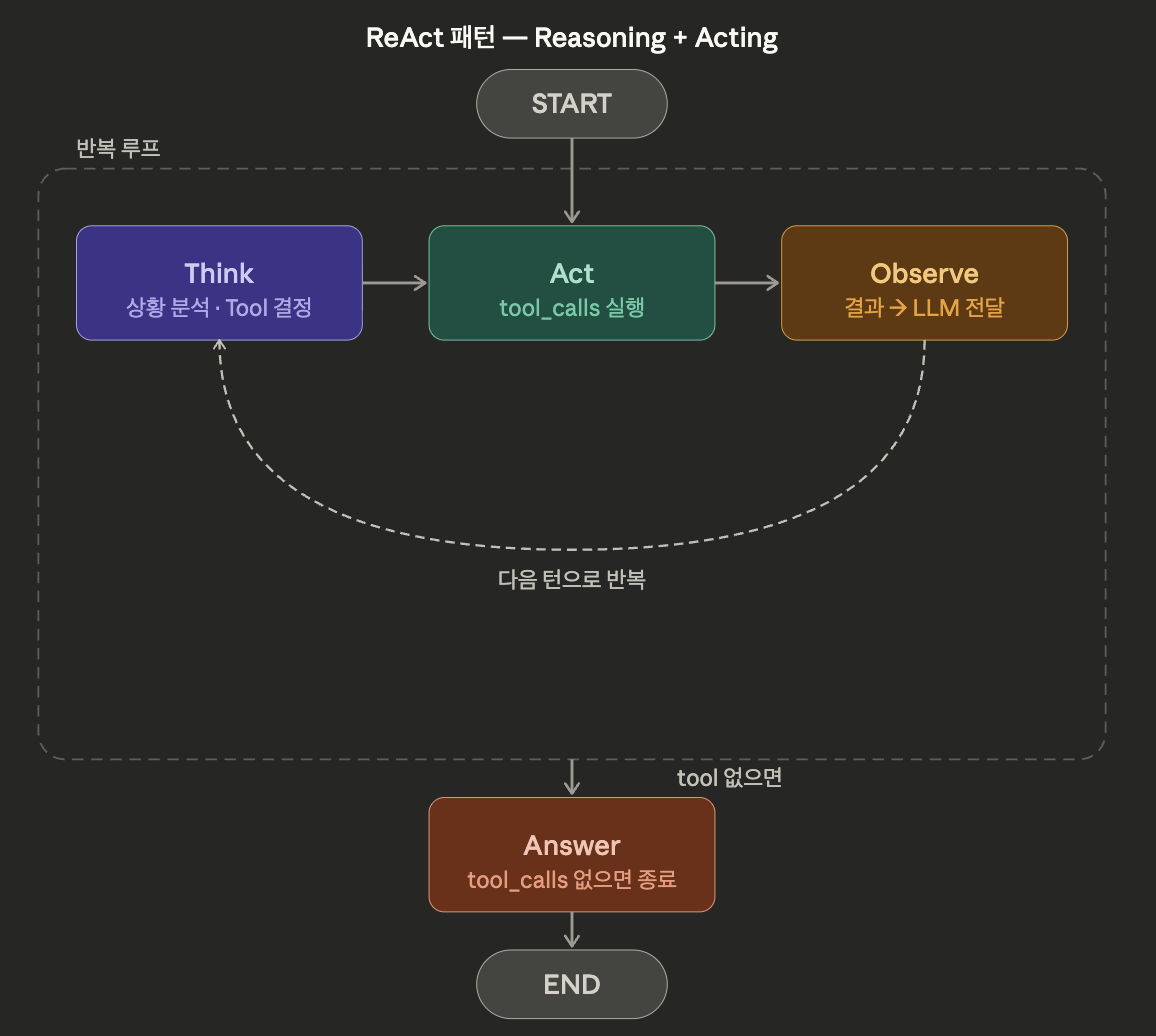
핵심은 **LLM이 다음 행동을 선택**한다는 점이다. 어떤 Tool을 호출할지, 몇 번 반복할지, 언제 멈출지를 매 턴마다 결정한다. 이때 모델의 내부 추론 과정 전체가 애플리케이션에 공개되는 것은 아니다. 애플리케이션은 `tool_calls`와 최종 응답을 관찰한다.


### Tool 정의

ReAct Agent가 사용할 Tool을 정의한다. 모델은 함수 구현이 아니라 **Tool 이름, docstring, 인자 타입으로 만들어진 schema**를 보고 Tool과 인자를 선택한다. 따라서 Tool 설명은 용도와 입력 형식을 구체적으로 작성해야 한다.

In [2]:
# 서버 시간 Tool
@tool(parse_docstring=True)
def get_current_time() -> str:
    """서버의 현재 로컬 날짜와 시간을 반환한다."""
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


tools = [get_current_time]
print(f"등록된 Function Tool: {[t.name for t in tools]}")

등록된 Function Tool: ['get_current_time']


### ReAct Agent 구현

In [3]:
llm = ChatGoogleGenerativeAI(model=MODEL_NAME)

# 직접 정의한 Function Tool 바인딩
llm_with_tools = llm.bind_tools(tools)

#### ToolNode와 tools_condition

이 두 가지가 ReAct 루프의 핵심이다.

##### ToolNode

LLM의 `tool_calls`를 받아서 실제 함수를 실행해주는 노드다. 내부적으로 다음을 자동 처리한다.

1. LLM 응답에서 `tool_calls`를 파싱 (함수 이름 + 인자)
2. 해당 함수를 실행
3. 결과를 `ToolMessage`로 감싸서 State에 추가

한 AI 메시지에 여러 `tool_calls`가 포함될 수도 있다. 서로 독립적인 호출이면 `ToolNode`가 함께 실행할 수 있으므로, Tool은 전역 상태를 함부로 변경하지 않도록 설계한다.

직접 구현하면 아래와 같다.

```python
for tool_call in response.tool_calls:
    tool_fn = tool_map[tool_call["name"]]
    result = tool_fn.invoke(tool_call["args"])
    messages.append(ToolMessage(content=result, tool_call_id=tool_call["id"]))
```

#### tools_condition

LLM 응답에 `tool_calls`가 있으면 `"tools"` 노드로, 없으면 `END`로 보내는 라우팅 함수다.

직접 구현하면 아래와 같다.

```python
def should_continue(state: MessagesState):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tools"
    return END
```

| 수동 구현 | LangGraph |
|---|---|
| `if response.tool_calls` 분기 | `tools_condition` 조건부 엣지 |
| Tool 실행 + `ToolMessage` 추가 | `ToolNode`가 자동 처리 |
| `messages` 리스트 직접 관리 | `MessagesState`가 자동 관리 |

#### 노드와 그래프 구성

`MessagesState`는 대화에서 주고받은 메시지들을 `messages` 키에 저장하는 State다. 내부에 `messages: Annotated[list, add_messages]`가 정의되어 있어 각 노드가 반환한 사용자 메시지, AI 메시지, Tool 메시지를 기존 기록에 누적한다. 대부분의 챗봇과 에이전트에서는 이 State만으로 충분하다.

In [4]:
def chatbot(state: MessagesState):
    """LLM을 호출하는 노드. Tool 호출이 필요하면 tool_calls가 포함된 메시지를 반환한다."""
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


# 그래프 구성
graph_builder = StateGraph(MessagesState)

# 노드 등록
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools))

# 엣지 연결
graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges("chatbot", tools_condition)
graph_builder.add_edge("tools", "chatbot")

graph = graph_builder.compile()

print("그래프 컴파일 완료")

그래프 컴파일 완료


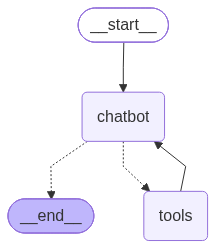

In [5]:
display(Image(graph.get_graph().draw_mermaid_png()))

`add_conditional_edges`에서 세 번째 인자(dictionary 매핑)가 생략되어 있다. 라우팅 함수의 반환값이 **노드 이름이나 `END`와 일치**하면 매핑을 생략할 수 있다.

```python
# dictionary 매핑 명시 (langgraph-basic 강의에서 다룬 방식)
graph_builder.add_conditional_edges("chatbot", tools_condition, {
    "tools": "tools",
    END: END,
})

# 라우팅 함수의 반환값이 노드 이름 / END와 일치하면 생략 가능
graph_builder.add_conditional_edges("chatbot", tools_condition)
```

`tools_condition`은 내부적으로 `"tools"` 또는 `END`를 반환하는데, 이 값들이 그래프의 노드 이름과 `END`에 그대로 대응하므로 매핑이 필요 없다.

### ReAct 실행 과정 확인

앞에서 배운 `invoke()`와 `stream()`을 사용해 ReAct Agent의 최종 결과와 `chatbot → tools → chatbot` 실행 과정을 확인한다.

#### 최종 결과 확인

In [7]:
question = "지금 몇 시야?"

result = graph.invoke({"messages": [("human", question)]})

for msg in result["messages"]:
    print(f"[{msg.type}] {msg.text[:300]}")
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        print(f"  -> Tool 호출: {[tc['name'] for tc in msg.tool_calls]}")
    print()

[human] 지금 몇 시야?

[ai] 
  -> Tool 호출: ['get_current_time']

[tool] 2026-09-09 10:24:09

[ai] 현재 시간은 **오전 10시 24분**입니다. (2026년 9월 9일)



### create_agent로 간단히 구성하기

앞에서는 ReAct 동작을 이해하기 위해 그래프를 직접 구성했다. LangChain의 `create_agent()`를 사용하면 같은 Tool 호출 반복 구조를 더 간단하게 만들 수 있다.

```python
from langchain.agents import create_agent

agent = create_agent(model=llm, tools=tools)
result = agent.invoke({"messages": [{"role": "human", "content": question}]})
```

### 실습 문제

제공된 `search_products`, `get_product` Tool을 사용해 상품 검색 Agent를 두 가지 방식으로 구성한다.

- `StateGraph`, `ToolNode`, `tools_condition`으로 Agent를 구성한다.
- `create_agent()`로 같은 Agent를 구성한다.
- 같은 질문을 실행해 두 방식의 결과를 확인한다.

In [12]:
PRODUCTS = {
    "A100": {"name": "무선 키보드", "price": 39_000, "stock": 12},
    "B200": {"name": "무선 마우스", "price": 25_000, "stock": 0},
    "C300": {"name": "노트북 거치대", "price": 32_000, "stock": 7},
}

@tool
def search_products(keyword: str) -> str:
    """상품명에 키워드가 포함된 상품을 검색한다."""
    keyword = keyword.strip().lower()
    matched = [
        (product_id, product["name"])
        for product_id, product in PRODUCTS.items()
        if keyword in product["name"].lower()
    ]

    if not matched:
        return "검색된 상품이 없습니다."

    return "\n".join(
        f"- {product_id}: {name}"
        for product_id, name in matched
    )

@tool
def get_product(product_id: str) -> str:
    """상품 id로 가격과 재고 정보를 조회한다"""
    product = PRODUCTS.get(product_id.upper())
    if product is None:
        return "상품을 찾을 수 없습니다."
    return (
        f"{product['name']}: {product['price']:,}원, "
        f"재고 {product['stock']}개"
    )

tools = [
    search_products,
    get_product
]

product_llm_with_tools = llm.bind_tools(tools)

def product_chatbot(state: MessagesState):
    """LLM을 호출하는 노드. Tool 호출이 필요하면 tool_calls가 포함된 메시지를 반환한다."""
    return {"messages": [product_llm_with_tools.invoke(state["messages"])]}

product_graph_builder = StateGraph(MessagesState)

product_graph_builder.add_node("chatbot", product_chatbot)
product_graph_builder.add_node("tools", ToolNode(tools))

product_graph_builder.add_edge(START, "chatbot")
product_graph_builder.add_conditional_edges("chatbot", tools_condition)
product_graph_builder.add_edge("tools", "chatbot")

product_graph = product_graph_builder.compile()

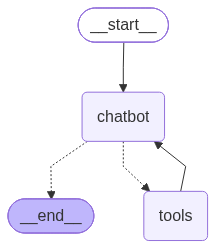

In [13]:
display(Image(product_graph.get_graph().draw_mermaid_png()))

In [15]:
question = "재고가 있는 상품은 뭐야?"

result = product_graph.invoke({"messages": [("human", question)]})

for msg in result["messages"]:
    print(f"[{msg.type}] {msg.text[:300]}")
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        print(f"  -> Tool 호출: {[tc['name'] for tc in msg.tool_calls]}")
    print()

[human] 재고가 있는 상품은 뭐야?

[ai] 
  -> Tool 호출: ['search_products']

[tool] - A100: 무선 키보드
- B200: 무선 마우스
- C300: 노트북 거치대

[ai] 
  -> Tool 호출: ['get_product', 'get_product', 'get_product']

[tool] 무선 키보드: 39,000원, 재고 12개

[tool] 무선 마우스: 25,000원, 재고 0개

[tool] 노트북 거치대: 32,000원, 재고 7개

[ai] 현재 재고가 있는 상품 목록은 다음과 같습니다.

* **무선 키보드** (A100): 39,000원 / **재고 12개**
* **노트북 거치대** (C300): 32,000원 / **재고 7개**

*(참고: **무선 마우스**(B200)는 현재 재고가 0개로 품절 상태입니다.)*



In [19]:
from langchain.agents import create_agent

question = "무슨 상품이 있어?"

product_agent = create_agent(model=llm, tools=tools)
result = product_agent.invoke({"messages": [{"role": "human", "content": question}]})
print(result["messages"][-1].text)

현재 준비되어 있는 상품 목록입니다.

1. **무선 키보드** (상품 ID: A100)
   - **가격:** 39,000원
   - **재고:** 12개

2. **무선 마우스** (상품 ID: B200)
   - **가격:** 25,000원
   - **재고:** 0개 (품절)

3. **노트북 거치대** (상품 ID: C300)
   - **가격:** 32,000원
   - **재고:** 7개
